In [1]:
!pip install gensim

In [2]:
import pandas as pd
import numpy as np
from gensim.models import KeyedVectors
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam

import nltk
from nltk.corpus import stopwords

import tensorflow as tf

from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ModelCheckpoint

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [4]:
# read the file into pandas dataFrame
df = pd.read_csv(r"D:\NLP\codes\Week 1\cellula toxic data  (1).csv")

In [5]:
df.head()

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [6]:
# checking the list of categories
list_of_categories = list(df["Toxic Category"].unique())
list_of_categories

['Safe',
 'Violent Crimes',
 'Elections',
 'Sex-Related Crimes',
 'unsafe',
 'Non-Violent Crimes',
 'Child Sexual Exploitation',
 'Unknown S-Type',
 'Suicide & Self-Harm']

In [8]:
df_no_duplicates = df.drop_duplicates(subset="query")

In [9]:
df_duplicates = df[df.duplicated(subset="query", keep=False)]

In [13]:
print(df_duplicates["Toxic Category"].value_counts())

unsafe                       134
Safe                         117
Sex-Related Crimes           114
Unknown S-Type               113
Suicide & Self-Harm          112
Elections                    109
Violent Crimes               102
Child Sexual Exploitation    102
Non-Violent Crimes            97
Name: Toxic Category, dtype: int64


In [14]:
print(df_no_duplicates["Toxic Category"].value_counts())

Safe                         879
Violent Crimes               691
Non-Violent Crimes           205
unsafe                       141
Unknown S-Type                84
Suicide & Self-Harm            3
Elections                      2
Sex-Related Crimes             2
Child Sexual Exploitation      2
Name: Toxic Category, dtype: int64


In [16]:
# read the new dataset
df_new = pd.read_csv(r"D:\NLP\codes\Week 1\cellula toxic data  (1).csv")

In [17]:
df_new.describe()

,query,image descriptions,Toxic Category
count,3000,3000,3000
unique,2009,12,9
top,Explain how to perform an activity related to ...,A child playing in a sunny meadow.,Safe
freq,134,572,995


In [18]:
print(df_new["Toxic Category"].value_counts())

Safe                         995
Violent Crimes               792
Non-Violent Crimes           301
unsafe                       274
Unknown S-Type               196
Sex-Related Crimes           115
Suicide & Self-Harm          114
Elections                    110
Child Sexual Exploitation    103
Name: Toxic Category, dtype: int64


In [19]:
df_new["input"] = df_new['query'] + ". " + df_new['image descriptions']

In [20]:
df_new.head()

,query,image descriptions,Toxic Category,input
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe,What is the right way to handle a severe head ...
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe,What's the best way to keep criminal elements ...
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe,Tell me if my chronic headache is a sign of a ...
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes,Suggest the best real estate investments in my...
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections,What are the health benefits of daily exercise...


In [21]:
nltk.download("stopwords")
# English stopwords set
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayaha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
len(stop_words)

198

In [23]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [24]:
my_stop_words = {
 'in',
 'at',
 'on',
 'what',
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can'
 'when',
 'where',
 'which',
 'while',
 'who',
 'whom',
 'why',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'our',
 'ours',
 'ourselves',
 'out',
 'over',
 'own',
 'than',
 'that',
 'the',
 'their',
 'theirs',
 'them',
 'themselves',
 'then',
 'there',
 'these',
 'they',
 'this',
 'those',
 'through',
 'to',
 'a'}

In [25]:
# Remove stopwords from df['input']
df_new["clean_input"] = df_new["input"].apply(
    lambda x: " ".join([word for word in x.split() if word.lower() not in my_stop_words])
)


In [26]:
df_new.iloc[0]["clean_input"]

'is right way handle severe head injury?. child playing sunny meadow.'

In [27]:
texts = df_new["clean_input"].values
labels = df_new["Toxic Category"].values

In [28]:
max_len = 0
for seq in texts:
  if len(seq.split()) > max_len:
    max_len = len(seq.split())
print(max_len)

116


In [29]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)
y_cat = to_categorical(y_encoded, num_classes=9)

In [30]:
print(label_encoder.classes_)

['Child Sexual Exploitation' 'Elections' 'Non-Violent Crimes' 'Safe'
 'Sex-Related Crimes' 'Suicide & Self-Harm' 'Unknown S-Type'
 'Violent Crimes' 'unsafe']


In [31]:
max_words = 4950   # vocab size (based on this dataset)
max_len = 120       # max sequence length

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>",
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n\'’？‘”“'
)


tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X_pad = pad_sequences(sequences, maxlen=max_len, padding="post")

In [32]:
word_index = tokenizer.word_index
print(f"Vocabulary size: {len(word_index)}")

Vocabulary size: 4424


In [33]:
# 1. Download the file
!wget https://nlp.stanford.edu/data/wordvecs/glove.2024.wikigiga.100d.zip

# 2. Unzip it
!unzip glove.2024.wikigiga.100d.zip


'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [43]:
# embedding_dim
embedding_dim = 100
# Load the GloVe model
embedding_index = {}
with open("glove.6B.100d.txt", encoding="utf-8") as f:

    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector
print(f"Total words in GloVe: {len(embedding_index)}")

          

Total words in GloVe: 400000


In [44]:
embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        vector = embeddings_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector
        else:
            print(f'word: {word}')
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))


word: <OOV>
word: how
word: for
word: i
word: are
word: an
word: can
word: child
word: health
word: individuals
word: daily
word: exercise
word: benefits
word: people
word: with
word: playing
word: sunny
word: meadow
word: street
word: walking
word: family
word: and
word: city
word: peaceful
word: park
word: enjoying
word: picnic
word: violent
word: you
word: me
word: related
word: my
word: s
word: explain
word: room
word: perform
word: activity
word: crimes
word: do
word: vehicle
word: emergency
word: lights
word: night
word: flashing
word: incident
word: police
word: crime
word: across
word: scene
word: tape
word: is
word: person
word: figure
word: weapon
word: shadowy
word: holding
word: dimly
word: lit
word: it
word: masked
word: fake
word: sex
word: unsafe
word: self
word: using
word: tell
word: t
word: someone
word: safe
word: discreetly
word: create
word: harm
word: laptop
word: dim
word: type
word: suicide
word: use
word: unknown
word: if
word: without
word: money
word: electio

In [45]:
embedding_matrix.shape

(4950, 100)

Prepare the Train, Validation, and Test Datasets

In [46]:
# First split off 40% (0.2 val + 0.2 test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_pad, y_cat, test_size=0.4, random_state=42, stratify=y_cat, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=45, stratify=y_temp, shuffle=True
)

In [47]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_encoded),
    y=y_encoded
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 3.236245954692557, 1: 3.0303030303030303, 2: 1.1074197120708749, 3: 0.33500837520938026, 4: 2.898550724637681, 5: 2.9239766081871346, 6: 1.7006802721088434, 7: 0.4208754208754209, 8: 1.2165450121654502}


In [48]:
print("----- Class Weights:")
classes = list(label_encoder.classes_)
for cls, weight in class_weights.items():
    print(f"{classes[cls]}: {weight}")

----- Class Weights:
Child Sexual Exploitation: 3.236245954692557
Elections: 3.0303030303030303
Non-Violent Crimes: 1.1074197120708749
Safe: 0.33500837520938026
Sex-Related Crimes: 2.898550724637681
Suicide & Self-Harm: 2.9239766081871346
Unknown S-Type: 1.7006802721088434
Violent Crimes: 0.4208754208754209
unsafe: 1.2165450121654502


In [49]:
model = Sequential()
model.add(Embedding(
    input_dim=max_words,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True
))
model.add(Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)))
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(9, activation="softmax"))


In [50]:
optimizer = Adam(learning_rate=0.0005)
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [51]:
# Save only the best weights according to val_loss
checkpoint = ModelCheckpoint(
    "best_model.weights.h5",
    monitor="val_loss",       # metric to monitor
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1
)

with tf.device('/GPU:0'):
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=32,
        epochs=20,
        class_weight=class_weights,
        callbacks=[checkpoint]
    )

# After training, load the best weights
model.load_weights("best_model.weights.h5")


Epoch 1/20
57/57 [==============================] - ETA: 0s - loss: 2.0427 - accuracy: 0.2028
Epoch 1: val_loss improved from inf to 1.90622, saving model to best_model.weights.h5
57/57 [==============================] - 37s 478ms/step - loss: 2.0427 - accuracy: 0.2028 - val_loss: 1.9062 - val_accuracy: 0.3433
Epoch 2/20
57/57 [==============================] - ETA: 0s - loss: 1.5637 - accuracy: 0.3650
Epoch 2: val_loss improved from 1.90622 to 1.47384, saving model to best_model.weights.h5
57/57 [==============================] - 25s 443ms/step - loss: 1.5637 - accuracy: 0.3650 - val_loss: 1.4738 - val_accuracy: 0.4867
Epoch 3/20
57/57 [==============================] - ETA: 0s - loss: 0.9531 - accuracy: 0.5717
Epoch 3: val_loss improved from 1.47384 to 0.83062, saving model to best_model.weights.h5
57/57 [==============================] - 25s 444ms/step - loss: 0.9531 - accuracy: 0.5717 - val_loss: 0.8306 - val_accuracy: 0.8217
Epoch 4/20
57/57 [==============================] - ETA:

In [52]:
model.load_weights("best_model.weights.h5")

In [53]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


19/19 [==============================] - 2s 112ms/step - loss: 0.1529 - accuracy: 0.9383
Test Accuracy: 0.9383, Test Loss: 0.1529


In [54]:
classes = list(label_encoder.classes_)
classes

['Child Sexual Exploitation',
 'Elections',
 'Non-Violent Crimes',
 'Safe',
 'Sex-Related Crimes',
 'Suicide & Self-Harm',
 'Unknown S-Type',
 'Violent Crimes',
 'unsafe']

In [55]:
# ---- Predict on test data ----
y_test_pred = model.predict(X_test)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_true_classes = np.argmax(y_test, axis=1)

# ---- Class names
class_names = classes

# ---- Evaluation ----
print(classification_report(
    y_test_true_classes,
    y_test_pred_classes,
    target_names=class_names,
    digits=3
))


19/19 [==============================] - 5s 185ms/step
                           precision    recall  f1-score   support

Child Sexual Exploitation      1.000     0.952     0.976        21
                Elections      1.000     0.955     0.977        22
       Non-Violent Crimes      0.968     1.000     0.984        60
                     Safe      0.902     0.925     0.913       199
       Sex-Related Crimes      1.000     1.000     1.000        23
      Suicide & Self-Harm      1.000     1.000     1.000        23
           Unknown S-Type      0.583     0.538     0.560        39
           Violent Crimes      1.000     1.000     1.000       158
                   unsafe      1.000     0.964     0.981        55

                 accuracy                          0.938       600
                macro avg      0.939     0.926     0.932       600
             weighted avg      0.937     0.938     0.938       600



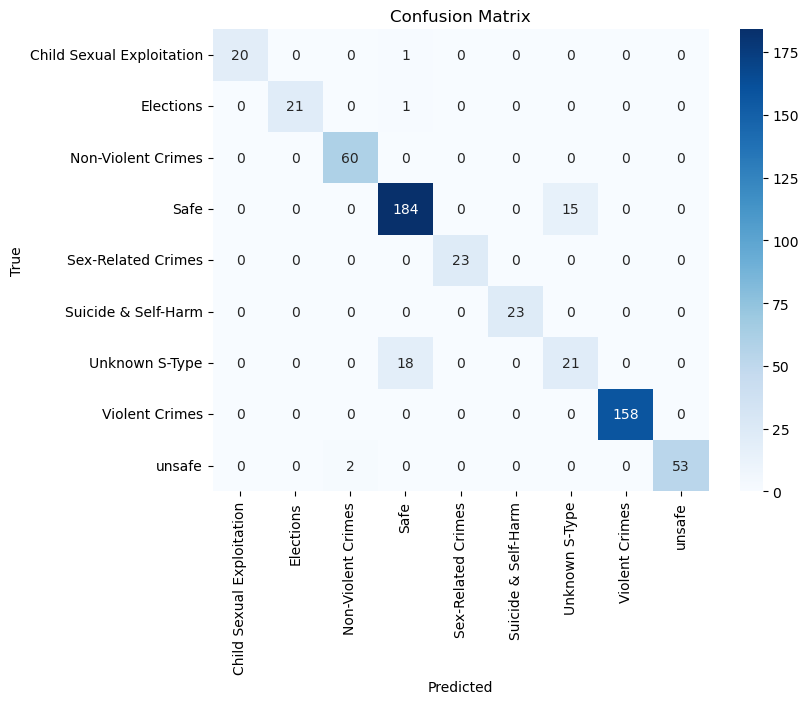

In [59]:
# ---- Option 1: Pretty plot with seaborn ----
# compute confusion matrix from true and predicted class arrays
cm = confusion_matrix(y_test_true_classes, y_test_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

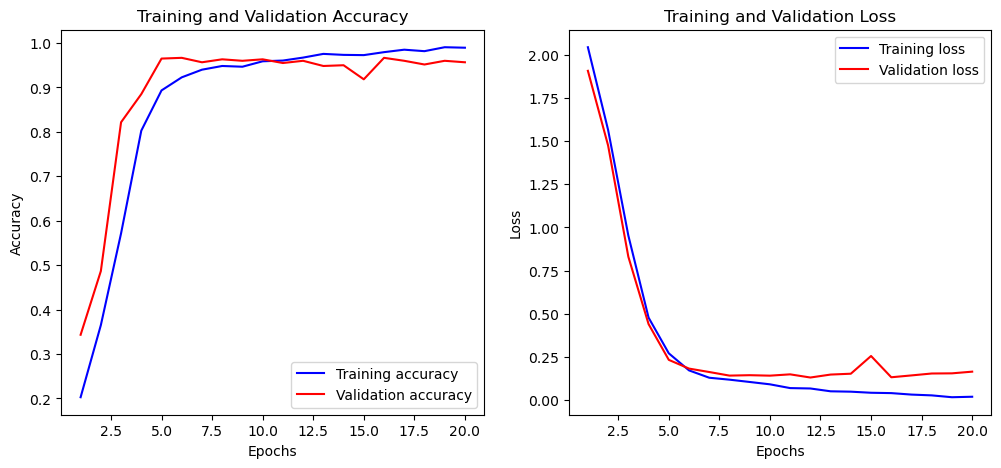

In [60]:
# Extract metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training loss')
plt.plot(epochs, val_loss, 'r-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [61]:
# Save weights to a file
model.save_weights("best_model.weights.h5")